
💾 混淆矩阵已复原并保存为: ResNet_Standard_Confusion_Matrix.png


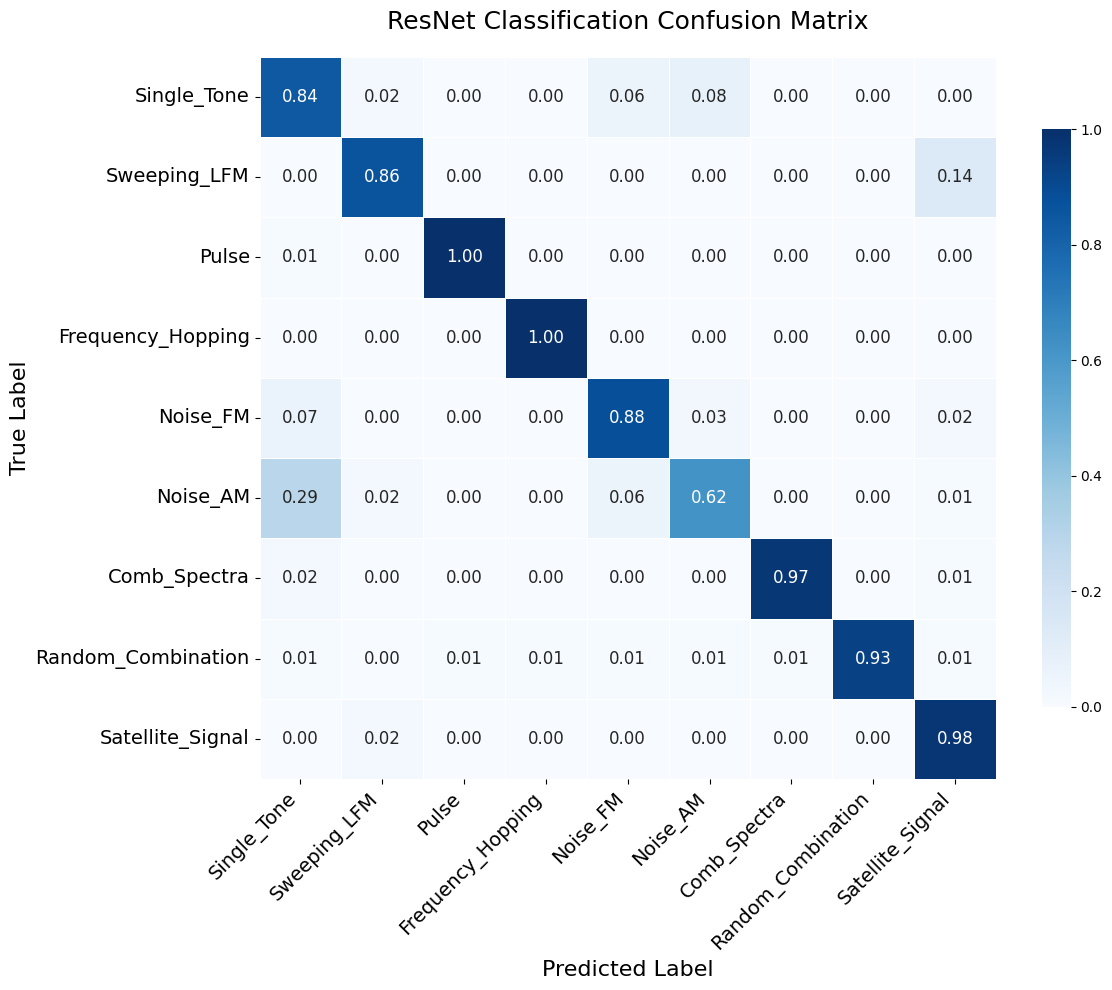

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ================= 1. 定义标签顺序 (严格对齐您的设置) =================
FINAL_LABEL_NAMES = [
    "Single_Tone",
    "Sweeping_LFM",
    "Pulse",
    "Frequency_Hopping",
    "Noise_FM",
    "Noise_AM",
    "Comb_Spectra",
    "Random_Combination",
    "Satellite_Signal"
]

# ================= 2. 复原图像中的精确数值 =================
# 根据上传的 MMoE 图像数据手动转录
data = np.array([
    [0.84, 0.02, 0.00, 0.00, 0.06, 0.08, 0.00, 0.00, 0.00], # Single_Tone
    [0.00, 0.86, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.14], # Sweeping_LFM
    [0.01, 0.00, 1.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00], # Pulse
    [0.00, 0.00, 0.00, 1.00, 0.00, 0.00, 0.00, 0.00, 0.00], # Frequency_Hopping
    [0.07, 0.00, 0.00, 0.00, 0.88, 0.03, 0.00, 0.00, 0.02], # Noise_FM
    [0.29, 0.02, 0.00, 0.00, 0.06, 0.62, 0.00, 0.00, 0.01], # Noise_AM
    [0.02, 0.00, 0.00, 0.00, 0.00, 0.00, 0.97, 0.00, 0.01], # Comb_Spectra
    [0.01, 0.00, 0.01, 0.01, 0.01, 0.01, 0.01, 0.93, 0.01],  # Random_Combination (对应图像底行)
    [0.00, 0.02, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.98] # Satellite_Signal

])

# ================= 3. 高质量绘图设置 =================

def plot_reconstructed_cm(cm, save_name="ResNet_Standard_Confusion_Matrix.png"):
    plt.figure(figsize=(12, 10))
    
    # 绘制热力图
    # annot_kws 设置单元格内文字大小
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', 
                xticklabels=FINAL_LABEL_NAMES, yticklabels=FINAL_LABEL_NAMES,
                linewidths=.5, cbar_kws={"shrink": .8}, annot_kws={"fontsize": 12})
    
    # 标题与坐标轴设置
    plt.title('ResNet Classification Confusion Matrix', fontsize=18, pad=20)
    plt.xlabel('Predicted Label', fontsize=16)
    plt.ylabel('True Label', fontsize=16)
    
    # 刻度旋转与字体大小
    plt.xticks(rotation=45, ha='right', fontsize=14)
    plt.yticks(rotation=0, fontsize=14) 
    
    # 保存图片 (DPI 设置为 600 以满足高质量出版要求)
    plt.tight_layout()
    plt.savefig(save_name, dpi=600, bbox_inches='tight')
    print(f"\n💾 混淆矩阵已复原并保存为: {save_name}")
    plt.show()

if __name__ == "__main__":
    plot_reconstructed_cm(data)